# 15 · Train the 3 heads + fusion for the **Llama-3.1-8B-Instruct** model (full metrics, isolated)

The 8B's heads + fusion were trained historically (the deployed `s1` artifacts), but **that run's notebook
outputs were never saved** — so there are no inline metric tables for the 8B for the thesis "model testing"
section. This notebook **re-trains all three heads (SEP + HalluShift + TSV) + the fusion from scratch** on
TriviaQA and renders the **full metric suite** — AUROC, AUPR, confusion matrix, Accuracy, Precision, Recall,
F1 — **for each head AND the fused model**, with a side-by-side comparison.

It reproduces the **exact deployed-8B recipe** (`tools/train_claim_heads.py` built `s1`; same Option-B recipe
nb13 used for the 1B), but everything is written to an **isolated tag `8bv2`** so **nothing touches the live
demo (`s1`) or the 1B (`l1b`)**. Promote later — only after live testing, and only if you choose to.

- **Model under test:** `Meta-Llama-3.1-8B-Instruct` (the demo's main model). TSV trains on this **Instruct**
  model (matches the served path).
- **Labels:** the 8B **self-judges** its own TriviaQA answers (substring-truthful + its own QA-judge rescue) —
  it's the strongest local model, so the decoupled-judge trick nb13 used for the weak 1B doesn't apply here.
  This is exactly how `s1` was labeled, so the numbers are directly comparable.
- **Robustness:** SEP + TSV are model-agnostic; HalluShift's feature count follows the layer count (71 for the
  8B's 32 layers) and is derived automatically below.

Run in `se_probes_env`. Cells 5 + 7 are the **GPU** passes. `SAVE=False` by default — review the metrics first.


In [1]:
import os, sys
os.environ.setdefault('HF_HOME', r'D:/LLAMA CACHE/huggingface')
# Use the HF token cached by `huggingface_hub.login` (the account with Llama access). Env-var tokens OVERRIDE
# the cached one in huggingface_hub, so drop any stale HF_TOKEN / HUGGING_FACE_HUB_TOKEN here or loading the
# gated model would 401. (token=True in engine.py then falls through to the cached token.)
for _v in ('HF_TOKEN', 'HUGGING_FACE_HUB_TOKEN'):
    os.environ.pop(_v, None)
sys.path.insert(0, os.path.abspath(os.path.join('..', 'hallking')))
sys.path.insert(0, os.path.abspath(os.path.join('..', 'tools')))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, torch, pickle, json
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
import retrain
from classifier import CombinedNN
ROOT = os.path.abspath('..')
DATA = os.path.join(ROOT, 'data'); ART = os.path.join(ROOT, 'artifacts')
SEED = 42
from huggingface_hub import get_token
print('torch', torch.__version__, '| cuda', torch.cuda.is_available(),
      '| HF token', (get_token() or '')[:6] + '...')


torch 2.7.1+cu118 | cuda True | HF token hf_miQ...


## 0 · Config
Swap the dataset, sample count, tag, etc. here. `BUILD=True` runs the GPU generate+cache once; set it `False`
afterwards to re-train heads from the cache without regenerating. `SAVE` gates writing the head artifacts
(keep `False` until the metrics look good). **`TAG='8bv2'` is isolated — it never overwrites the deployed
`s1` or the 1B's `l1b`.**

In [9]:
# == CONFIG =================================================================================
MODEL_ID       = 'meta-llama/Meta-Llama-3.1-8B-Instruct'   # model under test (the demo's main model)
JUDGE_MODEL    = None                                      # None -> 8B self-judges (strongest local model; matches s1)
DATASET        = 'triviaqa'                                # any key in run_dataset.load_qa
N_SAMPLES      = 1500                                      # questions (refusal-drop yields fewer rows)
OFFSET         = 0
TAG            = '8bv2'                                    # ISOLATED suffix: *_sentence_<TAG>, fusion_claim_<TAG>. NOT s1/l1b.
MAX_NEW_TOKENS = 64
EPOCHS_TSV     = 40
TSV_STR_LAYER  = None                                      # None -> round(0.28*num_layers) = 9/32 (the 8B's deployed layer)
FUSION_FEATS   = None                                      # None -> fuse all 3 heads; set ['tsv_margin'] to mirror the TSV-led demo
BUILD          = True                                      # True -> GPU generate+cache (run once); False -> reuse cache
SAVE           = True                                     # True -> write head artifacts + fusion (gate before deploy)
# ===========================================================================================
print(f'MODEL_ID    = {MODEL_ID}')
print(f'JUDGE_MODEL = {JUDGE_MODEL}  (None -> 8B self-judges)')
print(f'DATASET={DATASET} N={N_SAMPLES} offset={OFFSET} TAG={TAG} | BUILD={BUILD} SAVE={SAVE}')
assert TAG not in ('s1', 'l1b'), 'TAG collides with a deployed model — pick an isolated tag.'


MODEL_ID    = meta-llama/Meta-Llama-3.1-8B-Instruct
JUDGE_MODEL = None  (None -> 8B self-judges)
DATASET=triviaqa N=1500 offset=0 TAG=8bv2 | BUILD=True SAVE=True


## 1 · (GPU) Generate one factual sentence per question + cache features + self-judge labels
`gen_and_cache` (sentence regime) generates with the **8B**, caches the raw SEP (all-layer SLT stack) and
HalluShift features, drops refusals, then labels with the **resident 8B** (substring-truthful + QA-judge
rescue). With `JUDGE_MODEL=None` only one model is ever resident — the 8B both generates and judges, exactly
the path that built the deployed `s1`.

In [3]:
RAW_PARQUET = os.path.join(DATA, f'claims_sent_{TAG}.parquet')
RAW_SEPFEAT = os.path.join(DATA, f'claims_sent_{TAG}_sepfeats.npy')

if BUILD:
    df, sep_feats = retrain.gen_and_cache(
        DATASET, n=N_SAMPLES, offset=OFFSET, max_new_tokens=MAX_NEW_TOKENS,
        instruct_model=MODEL_ID, judge_model=JUDGE_MODEL,
        regime='sentence', label_method='llm_judge', drop_refusals=True, verbose=True)
    df['source'] = f'qa:{DATASET}'
    os.makedirs(DATA, exist_ok=True)
    df.to_parquet(RAW_PARQUET); np.save(RAW_SEPFEAT, sep_feats)
    print(f'saved {os.path.relpath(RAW_PARQUET, ROOT)} {df.shape} + '
          f'{os.path.relpath(RAW_SEPFEAT, ROOT)} {sep_feats.shape}')
else:
    df = pd.read_parquet(RAW_PARQUET).reset_index(drop=True)
    sep_feats = np.load(RAW_SEPFEAT)
    print(f'loaded cache {df.shape} + sep_feats {sep_feats.shape}')

y = df['hallucination'].to_numpy().astype(int)
hs_cols = [c for c in df.columns if c.startswith('hs_feat_')]
n_hs = len(hs_cols)
NUM_LAYERS = 2 * ((n_hs - 11) // 4 + 1)      # invert HalluShift count 4*((L/2)-1)+11 -> L (8B: 71 -> 32)
assert len(df) == len(sep_feats), f'row mismatch df={len(df)} sep_feats={len(sep_feats)}'
assert len(np.unique(y)) == 2, f'need both classes; halluc rate={y.mean()*100:.1f}%'
print(f'rows={len(df)} | halluc={y.mean()*100:.1f}% | HalluShift feats={n_hs} -> NUM_LAYERS={NUM_LAYERS} '
      f'| SEP width={sep_feats.shape[1]}')


Using the latest cached version of the dataset since trivia_qa couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'rc' at D:\LLAMA CACHE\huggingface\datasets\trivia_qa\rc\0.0.0\0f7faf33a3908546c6fd5b73a660e0f8ff173c2f (last modified on Wed Mar 18 11:01:14 2026).


[HallKing] loading meta-llama/Meta-Llama-3.1-8B-Instruct (4bit=True) ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [01:17<00:00,  3.76it/s]


[HallKing] model ready | num_layers=32 | device=cuda:0


generate+cache (triviaqa, sentence): 100%|██████████| 1500/1500 [55:45<00:00,  2.23s/q] 

  dropped 4 refusal answers (left the model's 'I don't know' alone)
  labelling 1496 answers (hybrid: substring-truthful + QA-judge rescue) ...
  [hybrid] 1193 truthful by substring; judging 303 non-match rows ...



QA-judge: 100%|██████████| 303/303 [02:01<00:00,  2.50claim/s]


[HallKing] model unloaded.
  labels (llm_judge): truthful=1260 halluc=236 (15.8%) over 1496 answers
saved data\claims_sent_8bv2.parquet (1496, 76) + data\claims_sent_8bv2_sepfeats.npy (1496, 135168)
rows=1496 | halluc=15.8% | HalluShift feats=71 -> NUM_LAYERS=32 | SEP width=135168


## 2 · (CPU + 1 GPU) Train the 3 heads on ONE shared split, score the held-out test
Stratified 75/25 split (seed 42), shared across heads so every per-head AUROC is on the **same** held-out
questions. SEP + HalluShift fit on CPU from the cached features; TSV trains on the **Instruct 8B** (GPU) — the
same model the demo serves, so TSV reads the representations it will see at inference. `NUM_LAYERS=32` and
`str_layer=9` are auto-derived for the 8B.

In [4]:
tr_idx, te_idx = train_test_split(np.arange(len(df)), test_size=0.25, stratify=y, random_state=SEED)
print(f'split: train={len(tr_idx)} test={len(te_idx)}')
auroc, aupr = {}, {}

# ---- SEP probe (CPU): fit on TRAIN, score all rows, AUROC on TEST ----
print('---- SEP probe (CPU) ----', flush=True)
sep_probe = retrain.retrain_sep(sep_feats[tr_idx].astype(np.float32), y[tr_idx], name=f'sentence_{TAG}')
Xf = sep_feats.astype(np.float32)
df['sep_entropy']  = sep_probe[0]['s_bmodel'].predict_proba(Xf)[:, 1]   # P(hallucinated)
df['sep_accuracy'] = sep_probe[0]['s_amodel'].predict_proba(Xf)[:, 1]   # P(truthful)
auroc['SEP'] = roc_auc_score(y[te_idx], df['sep_entropy'].to_numpy()[te_idx])
aupr['SEP']  = average_precision_score(y[te_idx], df['sep_entropy'].to_numpy()[te_idx])

# ---- HalluShift MLP (CPU): num_layers from THIS model -> correct feature count (8B: 32 -> 71 feats) ----
print('---- HalluShift MLP (CPU) ----', flush=True)
hs_state, hs_scaler = retrain.retrain_hallushift(df.iloc[tr_idx].reset_index(drop=True), y[tr_idx],
                                                 num_layers=NUM_LAYERS, seed=SEED)
Xhs = hs_scaler.transform(df[hs_cols].to_numpy(dtype=np.float64))
m = CombinedNN(NUM_LAYERS); m.load_state_dict(hs_state); m.eval()
with torch.no_grad():
    df['hallushift'] = torch.sigmoid(m(torch.tensor(Xhs, dtype=torch.float32))).numpy().ravel()
auroc['HalluShift'] = roc_auc_score(y[te_idx], df['hallushift'].to_numpy()[te_idx])
aupr['HalluShift']  = average_precision_score(y[te_idx], df['hallushift'].to_numpy()[te_idx])

# ---- TSV head (GPU): the Instruct 8B is the TSV base model; steering layer scaled to depth ----
str_layer = int(TSV_STR_LAYER) if TSV_STR_LAYER is not None else max(1, round(0.28 * NUM_LAYERS))
print(f'---- TSV head (GPU, {MODEL_ID} fp16) | str_layer={str_layer}/{NUM_LAYERS} ----', flush=True)
tsv_ckpt, tsv_margin = retrain.train_tsv(df, base_model=MODEL_ID, epochs=EPOCHS_TSV,
                                         str_layer=str_layer, tr_idx=tr_idx, te_idx=te_idx, verbose=True)
df['tsv_margin'] = tsv_margin
auroc['TSV'] = roc_auc_score(y[te_idx], tsv_margin[te_idx])
aupr['TSV']  = average_precision_score(y[te_idx], tsv_margin[te_idx])

summary = pd.DataFrame([{'head': k, 'heldout_AUROC': round(auroc[k], 3), 'heldout_AUPR': round(aupr[k], 3)}
                        for k in auroc]).set_index('head')
print('\n==== per-head HELD-OUT AUROC (sentence regime, 8B self-judge labels) ====')
print(summary.to_string())
summary


split: train=1122 test=374
---- SEP probe (CPU) ----
---- HalluShift MLP (CPU) ----
  [HalluShift retrain] best val AUROC=0.8516
---- TSV head (GPU, meta-llama/Meta-Llama-3.1-8B-Instruct fp16) | str_layer=9/32 ----
[HallKing] loading meta-llama/Meta-Llama-3.1-8B-Instruct (4bit=True) ...


Loading weights: 100%|██████████| 291/291 [01:11<00:00,  4.06it/s]


[HallKing] model ready | num_layers=32 | device=cuda:0
  [TSV ep 1/40] loss=0.4485 test AUROC=0.6748
  [TSV ep 2/40] loss=0.4264 test AUROC=0.7537
  [TSV ep 3/40] loss=0.4206 test AUROC=0.7592
  [TSV ep 4/40] loss=0.4238 test AUROC=0.6820
  [TSV ep 5/40] loss=0.4242 test AUROC=0.7487
  [TSV ep 6/40] loss=0.4330 test AUROC=0.7231
  [TSV ep 7/40] loss=0.4406 test AUROC=0.7176
  [TSV ep 8/40] loss=0.4348 test AUROC=0.7323
  [TSV ep 9/40] loss=0.4525 test AUROC=0.7190
  [TSV ep 10/40] loss=0.4411 test AUROC=0.7231
  [TSV ep 11/40] loss=0.4440 test AUROC=0.6998
  [TSV ep 12/40] loss=0.4389 test AUROC=0.6694
  [TSV ep 13/40] loss=0.4482 test AUROC=0.7028
  [TSV ep 14/40] loss=0.4448 test AUROC=0.6971
  [TSV ep 15/40] loss=0.4408 test AUROC=0.7166
  [TSV ep 16/40] loss=0.4471 test AUROC=0.6793
  [TSV ep 17/40] loss=0.4414 test AUROC=0.6782
  [TSV ep 18/40] loss=0.4413 test AUROC=0.6899
  [TSV ep 19/40] loss=0.4432 test AUROC=0.7002
  [TSV ep 20/40] loss=0.4441 test AUROC=0.7274
  [TSV ep 21/4

,heldout_AUROC,heldout_AUPR
head,,
SEP,0.777,0.453
HalluShift,0.800,0.459
TSV,0.759,0.362


## 3 · GO / NO-GO checkpoint
A head that **separates** (held-out AUROC ≳ 0.65) is worth fusing. If all three sit near 0.5 even with clean
labels, the signal does not carry sentence-level factuality — that's an honest finding; report it. (The 8B
demo ended up **TSV-led** because SEP/HalluShift were weak there — so don't be surprised if the same shows up
here.) Use the table above to decide `FUSION_FEATS` in the config — e.g. set it to `['tsv_margin']` if only
TSV separates, then re-run the fusion cell.

In [10]:
# Scored table for the fusion step — always written (intermediate data, not a deployed head).
split = np.array(['train'] * len(df), dtype=object); split[te_idx] = 'test'
scored = pd.DataFrame({'prompt': df['question'], 'source': df['source'], 'answer': df['answer'],
                       'sep_entropy': df['sep_entropy'], 'sep_accuracy': df['sep_accuracy'],
                       'hallushift': df['hallushift'], 'tsv_margin': df['tsv_margin'],
                       'label': y, 'split': split})
os.makedirs(DATA, exist_ok=True)
scored.to_parquet(os.path.join(DATA, f'claims_{TAG}.parquet'))
print(f'wrote data/claims_{TAG}.parquet (scored, with split col)')

if SAVE:
    for sub in ('sep', 'hallushift', 'tsv'):
        os.makedirs(os.path.join(ART, sub), exist_ok=True)
    with open(os.path.join(ART, 'sep', f'probes_sentence_{TAG}.pkl'), 'wb') as f:
        pickle.dump(sep_probe, f)
    torch.save(hs_state, os.path.join(ART, 'hallushift', f'hal_det_sentence_{TAG}_model.pth'))
    with open(os.path.join(ART, 'hallushift', f'hal_det_sentence_{TAG}_scaler.pkl'), 'wb') as f:
        pickle.dump(hs_scaler, f)
    torch.save(tsv_ckpt, os.path.join(ART, 'tsv', f'best_checkpoint_sentence_{TAG}.pt'))
    print(f'saved _sentence_{TAG} head artifacts (SEP / HalluShift / TSV) — s1/l1b untouched')
else:
    print('SAVE=False - head artifacts NOT written (review metrics first). Parquet written for the fusion test.')


wrote data/claims_8bv2.parquet (scored, with split col)
saved _sentence_8bv2 head artifacts (SEP / HalluShift / TSV) — s1/l1b untouched


## 4 · Fit + calibrate the fusion, and measure it (reuses `tools/train_claim_fusion.py`)
Group-split-safe fusion over the chosen heads on the out-of-sample test rows, with F1-calibrated thresholds.
Prints per-detector vs fused AUROC/AUPR/F1 + localization. Writes `models/fusion_claim_<TAG>.pkl` (+ thresholds)
only when `SAVE=True`. `res['metrics']` (used in cell 5) carries the FULL metric dict for every detector.

In [11]:
import train_claim_fusion as TCF
res = TCF.train(tag=TAG, feats=FUSION_FEATS, save=SAVE, verbose=True)
print('\nfusion thresholds:', {'t_med': res['t_med'], 't_high': res['t_high']})
res['summary']


[train_claim] d:\Github Repositories\HallKing\data\claims_8bv2.parquet: 1496 claims | halluc=15.8% | prompts=1496 | feats=['sep_entropy', 'hallushift', 'tsv_margin'] | sources={'qa:triviaqa': 1496}
[train_claim] using saved split: train=1122 test=374 (out-of-sample heads)
            AUROC   AUPR     F1
detector                       
SEP         0.777  0.453  0.459
HalluShift  0.800  0.459  0.500
TSV         0.759  0.362  0.433
FUSED       0.833  0.484  0.222

thresholds: T_MED=0.588  T_HIGH=0.98
localization top-1 = nan over 0 multi-claim prompts | within-passage AUROC = nan
saved models\fusion_claim_8bv2.pkl (+ thresholds json)

fusion thresholds: {'t_med': 0.588, 't_high': 0.98}


,AUROC,AUPR,F1
detector,,,
SEP,0.777,0.453,0.459
HalluShift,0.800,0.459,0.500
TSV,0.759,0.362,0.433
FUSED,0.833,0.484,0.222


## 5 · Full metrics + comparison — each head AND the fused model
The fusion step already computed every headline metric on the **same held-out TEST rows**: AUROC, AUPR,
Accuracy, Precision, Recall, F1, and the confusion matrix for **SEP / HalluShift / TSV / FUSED**. Render the
complete picture here for the thesis (table + confusion matrices + ROC/PR/confusion plots).

**Threshold convention (state this in the writeup):** the three heads use an **F1-optimal threshold picked on
TEST** (a best-case operating point — their raw scores aren't calibrated to a 0.5 cut), while **FUSED** uses
the **train-calibrated `t_high`**. So the head Precision/Recall/F1/confusion are oracle-thresholded; AUROC/AUPR
are threshold-free and fully comparable.

==== per-detector vs FUSED (held-out TEST, 8B, tag=8bv2) ====
             AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                                       
SEP         0.7769  0.4535    0.7727     0.3673  0.6102  0.4586
HalluShift  0.8003  0.4594    0.7701     0.3805  0.7288  0.5000
TSV         0.7594  0.3619    0.6711     0.2975  0.7966  0.4332
FUSED       0.8331  0.4841    0.8503     0.6154  0.1356  0.2222

confusion matrices  (rows=true [truthful, halluc], cols=pred):
  SEP         thr=0.037  TN=253 FP=62 FN=23 TP=36  | n=374 pos(halluc)=59
  HalluShift  thr=0.143  TN=245 FP=70 FN=16 TP=43  | n=374 pos(halluc)=59
  TSV         thr=-0.200  TN=204 FP=111 FN=12 TP=47  | n=374 pos(halluc)=59
  FUSED       thr=0.980  TN=310 FP=5 FN=51 TP=8  | n=374 pos(halluc)=59


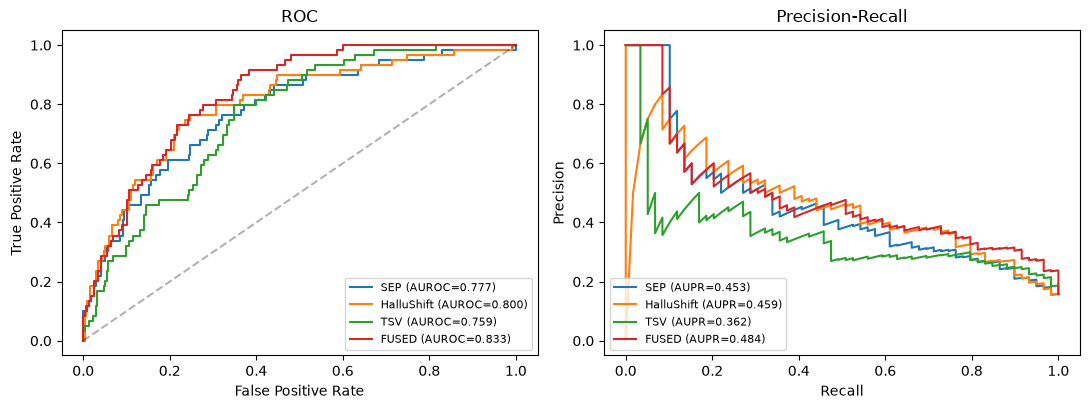

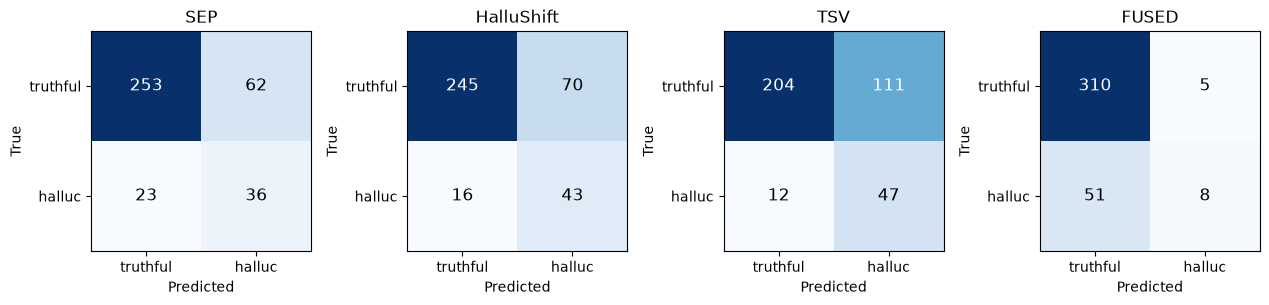

,AUROC,AUPR,Accuracy,Precision,Recall,F1
detector,,,,,,
SEP,0.7769,0.4535,0.7727,0.3673,0.6102,0.4586
HalluShift,0.8003,0.4594,0.7701,0.3805,0.7288,0.5000
TSV,0.7594,0.3619,0.6711,0.2975,0.7966,0.4332
FUSED,0.8331,0.4841,0.8503,0.6154,0.1356,0.2222


In [7]:
import matplotlib.pyplot as plt
from metrics import summary_table, plot_roc, plot_pr, plot_confusion

M = res['metrics']   # {'SEP','HalluShift','TSV','FUSED'} -> full metrics dict each (held-out TEST)
comparison = summary_table(M)          # AUROC, AUPR, Accuracy, Precision, Recall, F1
print(f'==== per-detector vs FUSED (held-out TEST, 8B, tag={TAG}) ====')
print(comparison.to_string())

print('\nconfusion matrices  (rows=true [truthful, halluc], cols=pred):')
for name, mm in M.items():
    cm = mm['confusion_matrix']
    print(f'  {name:11s} thr={mm["threshold"]:.3f}  TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}'
          f'  | n={mm["n"]} pos(halluc)={mm["positives(halluc)"]}')

# ROC + PR (all detectors share the held-out test rows)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
plot_roc(ax1, M); plot_pr(ax2, M); plt.tight_layout(); plt.show()

# confusion-matrix grid, one per detector
fig, axes = plt.subplots(1, len(M), figsize=(3.2 * len(M), 3))
for ax, (name, mm) in zip(np.atleast_1d(axes).ravel(), M.items()):
    plot_confusion(ax, mm['confusion_matrix'], title=name)
plt.tight_layout(); plt.show()
comparison


## 6 · (GPU, optional) End-to-end check on the SERVED path
Loads the full `HallKingPipeline` for the 8B exactly as the backend would (per-tag artifacts, fusion,
thresholds) and scores a few questions — **using the isolated `8bv2` artifacts, not the live `s1`**. A clean
run here means the heads are wired correctly; promoting `8bv2` to the demo is a separate manual step you take
only after you're happy with live testing. Needs `SAVE=True` (artifacts on disk).

In [8]:
fusion_pkl = os.path.join(ROOT, 'models', f'fusion_claim_{TAG}.pkl')
if SAVE and os.path.exists(fusion_pkl):
    from pipeline import HallKingPipeline
    from fusion import FusionModel
    pipe = HallKingPipeline(model_name=MODEL_ID, dataset=DATASET, separate_tsv=False,
                            sentence_tag=TAG, hs_tag=TAG).load()
    pipe.fusion = FusionModel.load(fusion_pkl)
    thr = json.load(open(os.path.join(ROOT, 'models', f'fusion_claim_{TAG}_thresholds.json')))
    pipe.t_med, pipe.t_high = float(thr['t_med']), float(thr['t_high'])
    for q in ['What is the capital of France?',
              'Who wrote the play Hamlet?',
              'In what year did the first man land on the moon?']:
        out = pipe.score_with_sentences(q, max_new_tokens=128)
        agg = out['aggregate']
        print('\nQ:', q)
        print('A:', out['answer'])
        print('  ->', agg['label'], '| fused =', agg['fused'],
              '| sep=%.3f hs=%.3f tsv=%.3f' % (agg['sep_entropy'], agg['hallushift'], agg['tsv_margin']))
else:
    print('skip: set SAVE=True and run the save + fusion cells first (needs artifacts on disk).')


skip: set SAVE=True and run the save + fusion cells first (needs artifacts on disk).
